# Bluesky Data Science
## Part 09 - Algorithmic Curation and Governance: Custom Feeds, Lists, Labelers, and Starter Packs: Custom Feeds, Lists, Labelers, and Starter Packs

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: On most platforms "the algorithm" is a black box you can only audit from the outside — or from the inside, if the platform lets you in. On Bluesky, feed algorithms, moderation labels, lists, and starter packs are *public infrastructure*: anyone can publish them and anyone can query them. This notebook treats them as objects of study, running a small algorithm audit that compares the composition of several custom feeds against a no-algorithm baseline, and then mapping the rest of Bluesky's governance stack.

### What is an algorithm audit?

An **algorithm audit** is a research design that treats an algorithmic system the way investigators treat an opaque institution: probe it systematically, record what it does, and compare its behavior against a baseline or a standard. The name is borrowed from housing-discrimination *audit studies*, in which matched pairs of testers applied for the same apartment to detect differential treatment. [Sandvig et al. (2014)](https://websites.umich.edu/~csandvig/research/Auditing%20Algorithms%20--%20Sandvig%20--%20ICA%202014%20Data%20and%20Discrimination%20Preconference.pdf) imported the idea into platform research and catalogued the main designs (code audits, scraping audits, sock-puppet audits, crowdsourced audits); [Metaxa et al. (2021)](https://doi.org/10.1561/1100000083) is a book-length, accessible survey of the method. Keep that taxonomy in mind — by the end of this notebook you will have run a *scraping audit*, and you will understand precisely why the other designs still matter.

### Auditing the algorithm, then and now

For fifteen years, the question "what does the algorithm amplify?" could only be answered two ways on Twitter. You could be *inside* the company: [Huszár et al. (2022)](https://doi.org/10.1073/pnas.2025334119) measured the algorithmic amplification of political content by running a massive experiment on Twitter's own servers, comparing users held on reverse-chronological timelines against users given the algorithmic ranking — a study design literally impossible without internal access. Or you could probe from *outside*: [Bandy & Diakopoulos (2021)](https://doi.org/10.1145/3449152) built sock-puppet accounts that followed identical sets of news sources and recorded what the curated timeline showed them, inferring the algorithm's behavior from its outputs. Both designs treat the ranking system as a sealed box.

Bluesky's architecture changes the terms of this problem. The [AT Protocol](https://atproto.com) — the open protocol Bluesky runs on — *unbundles* curation and moderation from the platform:

* **Feed generators** are services, published as public records, that return a ranked list of posts — a *custom feed* is just a feed generator someone has published ([docs](https://docs.bsky.app/docs/advanced-guides/custom-feeds)). Anyone can publish one; anyone can request any feed's current contents through `app.bsky.feed.getFeed`. The Discover feed that millions of users see is queryable by the same endpoint as a hobbyist's feed.
* **Labelers** are independent moderation services that emit *labels* (like `porn`, `graphic-media`, or `!hide`) on accounts and posts ([docs](https://docs.bsky.app/docs/advanced-guides/moderation)). Clients subscribe to labelers and decide what to do with their labels — Bluesky calls this [*stackable moderation*](https://bsky.social/about/blog/03-12-2024-stackable-moderation). Labels are queryable through `com.atproto.label.queryLabels`.
* **Lists** are public rosters of accounts used for curation (list feeds) and moderation (shared mute/block lists).
* **Starter packs** are onboarding bundles — a list of accounts plus optional feeds — that shape which network a newcomer lands in.

None of this makes audits trivial: as we will see, the *personalized* layer is still invisible without logging in as a user. But the skeleton of the curation system — what each feed serves, what each labeler flags, who is on which list — is open to any researcher with an HTTP client.

### Learning objectives

After working through this notebook you will be able to:

1. Discover and describe published feed generators with `app.bsky.feed.getActorFeeds` and `app.bsky.feed.getFeedGenerators`.
2. Collect samples of posts from custom feeds via `app.bsky.feed.getFeed`, including calling XRPC endpoints directly when the SDK's typed models lag behind the protocol.
3. Run an audit-style comparison of feed composition: author concentration (top-10 share, HHI, Gini), recency, engagement, language mix, and media share.
4. Measure audience overlap between feeds with Jaccard similarity.
5. Describe lists, starter packs, and labelers as governance infrastructure, and query moderation labels from a labeler service.
6. Discuss what algorithm audits can and cannot establish on a platform where algorithms are inspectable but personalization is private.

## Setup

We will use the same toolkit as the earlier parts — `pandas`, `numpy`, and `matplotlib` — plus `requests` for talking to XRPC endpoints directly. The helper module for this part is [`feeds.py`](feeds.py), which collects the reusable functions we develop below.

In [1]:
# Talking to web services directly
import requests

# APIs speak JSON
import json

# Politeness between requests, and recording when we collected
import time
from datetime import datetime, timezone
from pathlib import Path

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

As in every part of this series, `get_client()` returns an authenticated client if you have saved an `atproto.json` credentials file (see Part 00), and otherwise falls back to the unauthenticated **public AppView** — the read-only aggregation service at `https://public.api.bsky.app` that assembles the network's raw records into the hydrated views (posts with their like counts, profiles with their follower counts) the official app displays. Everything in this notebook works without logging in — which is rather the point: an algorithm audit you can run without the platform's permission.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


Each part of this series pairs its notebook with a small helper module collecting the reusable functions we develop along the way — here it is [`feeds.py`](feeds.py), which holds the raw collection, flattening, and metric functions we will meet one at a time below. We also create the `data/` directory where this part saves its (small) archives, so analysis cells later in the notebook can be rerun from disk without touching the network.

In [3]:
# The helper module developed in this notebook
import feeds

# Make sure the data directory exists for the archives we will save
Path('data').mkdir(exist_ok=True)

## 1. Feed generators are public records

Two pieces of AT Protocol vocabulary before we begin. A **DID** (*decentralized identifier*, [spec](https://atproto.com/specs/did)) is an account's permanent, machine-readable identity — a string like `did:plc:z72i7hdynmk6r22z27h6tvur` that never changes even when the human-readable handle (`bsky.app`) does. An **AT-URI** ([spec](https://atproto.com/specs/at-uri-scheme)) is the protocol's addressing scheme for records: `at://<DID>/<record type>/<record key>` names one specific record in one specific account's public repository, the way a URL names a web page.

On Bluesky, a feed algorithm is announced to the world as an `app.bsky.feed.generator` record in its publisher's repository. Each feed therefore has a stable AT-URI of the form `at://<publisher DID>/app.bsky.feed.generator/<name>`, plus public metadata: a display name, a description, and a count of users who have liked (roughly, saved) the feed. If you have ever wondered what "the algorithm" *is*, on this platform the answer is concrete: a record you can look up, pointing at a service you can query. (If you want to publish your own, the official [custom feed starter template](https://docs.bsky.app/docs/starter-templates/custom-feeds) walks through it.)

`app.bsky.feed.getActorFeeds` lists every feed generator a given account publishes. Let's start with the official `bsky.app` account, which publishes the feeds most users encounter first — including **Discover**, the platform's flagship algorithmic feed.

In [4]:
actor_feeds = client.app.bsky.feed.get_actor_feeds({'actor': 'bsky.app', 'limit': 50})

bsky_feeds_df = pd.DataFrame(
    [
        {
            'display_name': f.display_name,
            'like_count': f.like_count,
            'description': f.description,
            'uri': f.uri,
        }
        for f in actor_feeds.feeds
    ]
).sort_values('like_count', ascending=False).reset_index(drop=True)

print(f"{len(bsky_feeds_df)} feed generators published by bsky.app")
bsky_feeds_df

7 feed generators published by bsky.app


,display_name,like_count,description,uri
0,Popular With Friends,41157,A mix of popular content from accounts you fol...,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
1,Discover,39099,Trending content from your personal network,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
2,What's Hot Classic,10384,The original What's Hot experience,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
3,Video,6943,Trending videos in the Bluesky network,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
4,Bluesky Team,5849,Posts from members of the Bluesky Team,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
5,Mutuals,5367,See posts from your mutual follows,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...
6,Best of Follows,2621,See top content from people you follow,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...


Note how each row is an *algorithm with a public address*. Some of these (Discover, Popular With Friends, Mutuals, Best of Follows) describe themselves in terms of "your" network — they are personalized, a distinction that will matter shortly.

The official account is only one publisher among thousands. Anyone can run a feed generator, and some third-party feeds rival the official ones in popularity. `app.bsky.feed.getFeedGenerators` hydrates metadata for any batch of feed URIs, so we can look up two well-known community feeds — the **Science** feed (a curated feed of verified scientists, run by `bossett.social`) and the **News** feed (headlines from verified news organizations, run by `aendra.com`) — alongside two official ones.

In [5]:
CANDIDATE_FEEDS = {
    'Discover': f'at://{feeds.BSKY_APP_DID}/app.bsky.feed.generator/whats-hot',
    "What's Hot Classic": f'at://{feeds.BSKY_APP_DID}/app.bsky.feed.generator/hot-classic',
    'Science': 'at://did:plc:jfhpnnst6flqway4eaeqzj2a/app.bsky.feed.generator/for-science',
    'News': 'at://did:plc:kkf4naxqmweop7dv4l2iqqf5/app.bsky.feed.generator/verified-news',
}

try:
    generators = client.app.bsky.feed.get_feed_generators({'feeds': list(CANDIDATE_FEEDS.values())})
    generator_df = pd.DataFrame(
        [
            {
                'display_name': g.display_name,
                'publisher': g.creator.handle,
                'like_count': g.like_count,
                'description': (g.description or '').replace('\n', ' ')[:90],
            }
            for g in generators.feeds
        ]
    )
except Exception as error:
    print(f"Could not resolve some feed URIs ({type(error).__name__}); falling back to bsky.app's feeds only.")
    generator_df = bsky_feeds_df.head(4).rename(columns={'uri': 'feed_uri'})

generator_df

,display_name,publisher,like_count,description
0,Discover,bsky.app,39099,Trending content from your personal network
1,What's Hot Classic,bsky.app,10384,The original What's Hot experience
2,Science,bossett.social,29344,The Science Feed. A curated feed from Bluesky ...
3,📰 News,aendra.com,23963,Headlines from verified news organisations in ...


The AppView also offers a discovery endpoint, `app.bsky.feed.getSuggestedFeeds`, which returns the feeds Bluesky would suggest to a user browsing the feed marketplace. It works without authentication (you get the generic, non-personalized suggestions), and it is a useful way to build a sampling frame of *prominent* feeds for a larger audit.

In [6]:
try:
    suggested = client.app.bsky.feed.get_suggested_feeds({'limit': 10})
    for f in suggested.feeds:
        print(f"{f.like_count:>8,}  {f.display_name}  ({f.creator.handle})")
except Exception as error:
    print(f"getSuggestedFeeds unavailable without authentication here: {type(error).__name__}")

  39,099  Discover  (bsky.app)
  41,157  Popular With Friends  (bsky.app)
  28,707  Mutuals  (skyfeed.xyz)
  29,344  Science  (bossett.social)
  32,752  Artists: Trending  (bsky.art)
  23,963  📰 News  (aendra.com)
  28,112  Blacksky  (rude1.blacksky.team)
  49,997  For You  (spacecowboy17.bsky.social)
  10,384  What's Hot Classic  (bsky.app)


One feed we *cannot* fetch anonymously is the **Following** timeline — the reverse-chronological feed of accounts a user follows. There is no "anyone's" timeline: `app.bsky.feed.getTimeline` is defined relative to a logged-in account. This is the first boundary of unauthenticated auditing, so we guard it the way this series always guards privileged endpoints.

In [7]:
if is_authenticated(client):
    timeline = client.get_timeline(limit=5)
    for item in timeline.feed:
        print(item.post.author.handle, '-', item.post.record.created_at)
else:
    print("Requires authentication: the Following timeline is defined relative to a logged-in")
    print("account, so there is no anonymous view of it. We will build a reverse-chronological")
    print("baseline from a public list feed instead (Section 2).")

Requires authentication: the Following timeline is defined relative to a logged-in
account, so there is no anonymous view of it. We will build a reverse-chronological
baseline from a public list feed instead (Section 2).


## 2. Sampling posts from custom feeds

`app.bsky.feed.getFeed` returns the current contents of any published feed — the same endpoint the official app calls when you open a feed. Before collecting in bulk, two practical lessons learned the hard way.

**Lesson 1: personalized feeds have no "view from nowhere".** Feeds like *Popular With Friends* rank posts relative to a specific viewer. Ask for them without authentication and the feed generator simply errors out — there is no answer to "popular with *whose* friends?". Watch what happens:

In [8]:
try:
    client.app.bsky.feed.get_feed(
        {'feed': f'at://{feeds.BSKY_APP_DID}/app.bsky.feed.generator/with-friends', 'limit': 5}
    )
    print("Popular With Friends returned posts - you are probably running this authenticated,")
    print("so the feed was ranked relative to *your* account.")
except Exception as error:
    print(f"{type(error).__name__}: the 'Popular With Friends' feed generator refused our")
    print("unauthenticated request (the upstream service returned a 5xx error).")
    print()
    print("Personalized feeds are only observable from the standpoint of a particular user -")
    print("exactly the layer Huszar et al. (2022) needed internal access to study.")

NetworkError: the 'Popular With Friends' feed generator refused our
unauthenticated request (the upstream service returned a 5xx error).

Personalized feeds are only observable from the standpoint of a particular user -
exactly the layer Huszar et al. (2022) needed internal access to study.


**Lesson 2: lexicons evolve faster than SDKs.** A **lexicon** is AT Protocol's schema language ([guide](https://atproto.com/guides/lexicon)): every record type (`app.bsky.feed.post`), embed type (`app.bsky.embed.images`), and API method (`app.bsky.feed.getFeed`) is defined by a published lexicon schema, named by a reverse-domain identifier. The network can mint new lexicon types at any time — and software that has not heard of them yet must cope.

That is exactly the trap we hit. The atproto SDK validates every response against typed models built from the lexicons it shipped with. That is normally a feature, but feed responses mix in whatever embed types the network has recently invented (while developing this notebook, a brand-new `app.bsky.embed.gallery` type crashed the SDK's parser, costing us entire pages of results). For bulk collection we therefore call the XRPC endpoints directly with `requests` and work with plain JSON dictionaries — the exact same HTTP requests the SDK would make, minus the strict validation. `feeds.xrpc_get` is a one-liner wrapper:

```python
def xrpc_get(endpoint, params=None, base_url=PUBLIC_APPVIEW, timeout=30):
    response = requests.get(f"{base_url}/xrpc/{endpoint}", params=params, timeout=timeout)
    response.raise_for_status()
    return response.json()
```

and `feeds.fetch_feed_posts` wraps it in the familiar cursor-pagination loop from Part 01 (page through `getFeed` with `cursor`, sleep 0.1 s between pages, stop at a target count). Let's pull roughly **150 posts from each of our four candidate feeds**. Note that we record the retrieval timestamp for every feed: a feed is a *moving target*, and an audit observation is meaningless without its collection time. Note also the `try`/`except` around each feed: these are live third-party services that can error or vanish, and a resilient audit pipeline skips a dead feed rather than crashing.

In [9]:
samples = {}       # feed name -> list of raw feed items
collection_log = {}  # feed name -> retrieval timestamp

for name, uri in CANDIDATE_FEEDS.items():
    retrieved_at = datetime.now(timezone.utc)
    try:
        items = feeds.fetch_feed_posts(uri, target=150)
    except requests.HTTPError as error:
        print(f"{name}: skipped ({error.response.status_code} from the feed generator)")
        continue
    samples[name] = items
    collection_log[name] = retrieved_at
    print(f"{name}: {len(items)} posts retrieved at {retrieved_at:%Y-%m-%d %H:%M} UTC")
    time.sleep(0.5)

Discover: 150 posts retrieved at 2026-06-10 11:02 UTC


What's Hot Classic: 150 posts retrieved at 2026-06-10 11:02 UTC


Science: 150 posts retrieved at 2026-06-10 11:02 UTC


News: 150 posts retrieved at 2026-06-10 11:02 UTC


### A no-algorithm baseline

Huszár et al. (2022) could compare algorithmic timelines against users held on reverse-chronological ones. Our public analogue is a **list feed**: `app.bsky.feed.getListFeed` returns the posts of a list's members in pure reverse-chronological order — no ranking model at all. We will use the official `bsky.app` account's *Community Showcase* curation list (we examine lists properly in Section 5) as a fixed roster, giving us a "what does no algorithm look like?" comparison sample.

This baseline is not a perfect stand-in for a Following timeline — its roster is small and curated by Bluesky — but it isolates the property we care about: *chronology versus ranking*.

In [10]:
lists_response = client.app.bsky.graph.get_lists({'actor': 'bsky.app', 'limit': 50})

baseline_list = next(
    (l for l in lists_response.lists if l.purpose.endswith('curatelist')),
    lists_response.lists[0] if lists_response.lists else None,
)

if baseline_list is None:
    print("bsky.app currently publishes no lists; proceeding without a baseline sample.")
else:
    print(f"Baseline roster: '{baseline_list.name}' ({baseline_list.list_item_count} members)")
    retrieved_at = datetime.now(timezone.utc)
    samples['Baseline (list feed)'] = feeds.fetch_list_feed_posts(baseline_list.uri, target=150)
    collection_log['Baseline (list feed)'] = retrieved_at
    print(f"Baseline (list feed): {len(samples['Baseline (list feed)'])} posts "
          f"retrieved at {retrieved_at:%Y-%m-%d %H:%M} UTC")

Baseline roster: 'Community Showcase' (21 members)


Baseline (list feed): 150 posts retrieved at 2026-06-10 11:02 UTC


### Flattening into a tidy archive

`feeds.posts_to_dataframe` flattens each nested feed item into one row of *audit-relevant* fields: who posted, when (with the post's age at retrieval), engagement counts, declared language, and embed/media type.

Notice what we deliberately do **not** keep: the post text. A composition audit asks *who and what kind*, not *what was said*, and the data-minimization principle from Part 01 says you should not collect fields your research question does not require — every column you store is a column you are responsible for.

In [11]:
posts_df = pd.concat(
    [
        feeds.posts_to_dataframe(items, feed_name, collection_log[feed_name])
        for feed_name, items in samples.items()
    ],
    ignore_index=True,
)

print(f"{len(posts_df)} posts across {posts_df['feed'].nunique()} feeds")
posts_df.head()

749 posts across 5 feeds


,feed,uri,author_did,author_handle,created_at,indexed_at,retrieved_at,like_count,repost_count,reply_count,quote_count,lang,embed_type,has_media,text_chars,via_repost,age_hours
0,Discover,at://did:plc:pdtzhpyq7bm7ts7wwty6gdlg/app.bsky...,did:plc:pdtzhpyq7bm7ts7wwty6gdlg,robot-rosie.bsky.social,2026-06-10 06:01:59.851000+00:00,2026-06-10 06:02:30.463000+00:00,2026-06-10 11:02:20.609749+00:00,63,3,7,0,tr,images,True,24,False,5.005766
1,Discover,at://did:plc:qobvnkudcv3zlaklxxjduqoi/app.bsky...,did:plc:qobvnkudcv3zlaklxxjduqoi,motherjones.com,2026-06-10 03:37:44.423000+00:00,2026-06-10 03:37:45.659000+00:00,2026-06-10 11:02:20.609749+00:00,492,260,26,14,NaN,external,False,271,False,7.410052
2,Discover,at://did:plc:jjf2uoixeehlvcn3cpbyul5v/app.bsky...,did:plc:jjf2uoixeehlvcn3cpbyul5v,tadeutadeu.bsky.social,2026-06-10 09:50:03.665000+00:00,2026-06-10 09:50:05.471000+00:00,2026-06-10 11:02:20.609749+00:00,72,10,1,1,pt,video,True,8,False,1.204707
3,Discover,at://did:plc:yf6hctt2ug3qyfty4in64yob/app.bsky...,did:plc:yf6hctt2ug3qyfty4in64yob,politico.com,2026-06-09 16:25:51.618000+00:00,2026-06-09 16:25:53.060000+00:00,2026-06-10 11:02:20.609749+00:00,5661,1592,191,89,en,external,False,197,False,18.608053
4,Discover,at://did:plc:nl32untxngcg74dl3w7scd74/app.bsky...,did:plc:nl32untxngcg74dl3w7scd74,us.theguardian.com,2026-06-09 14:50:53.748000+00:00,2026-06-09 14:50:55.472000+00:00,2026-06-10 11:02:20.609749+00:00,596,281,105,31,en,external,False,277,False,20.190795


We save the archive immediately, before any analysis. The file format is [Parquet](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_parquet.html), a compressed columnar format that preserves dtypes (including our timezone-aware timestamps) and is far smaller than CSV — important because we keep each part's `data/` directory under a couple of megabytes. Saving first is audit hygiene: the feeds will have moved on by tomorrow, but this snapshot, stamped with its retrieval times, is now frozen evidence that any collaborator can reanalyze (Section 8).

In [12]:
posts_path = Path('data') / 'feed_posts.parquet'
posts_df.to_parquet(posts_path, index=False)
print(f"Saved {posts_path} ({posts_path.stat().st_size / 1024:.0f} KB)")

Saved data/feed_posts.parquet (76 KB)


## 3. Auditing feed composition

Now the centerpiece: what does each algorithm actually *serve*? Following the logic of Bandy & Diakopoulos (2021) — characterize the curated output and compare it against a chronological counterfactual — we compute a panel of composition metrics per feed:

* **Author concentration.** Does the feed amplify a few voices or many? We use three complementary measures of the distribution of posts over authors: the share contributed by the **top 10 authors**, the **Herfindahl–Hirschman index** (the economists' market-concentration measure: the sum of squared author shares, $\mathrm{HHI} = \sum_i s_i^2$, where $1/n$ means perfectly even and 1 means a single author), and the **Gini coefficient** (0 = every author contributes equally, → 1 = maximal inequality).
* **Recency.** The median and 90th-percentile *age* of posts at the moment we retrieved them. A trending algorithm should serve hours-old posts; a sparse chronological roster may surface much older ones.
* **Engagement.** Median and 90th-percentile like counts. Ranked feeds that select on popularity should show dramatically higher engagement than a feed that selects on time alone — selection, not causation!
* **Language mix and media share.** What fraction of posts declare English, how many languages appear, and how often posts carry images or video.

These are implemented in `feeds.feed_composition`; the docstrings show the formulas.

In [13]:
comparison = feeds.feed_composition(posts_df)

# Save the comparison table alongside the post archive
comparison_path = Path('data') / 'feed_comparison.csv'
comparison.to_csv(comparison_path)
print(f"Saved {comparison_path} ({comparison_path.stat().st_size / 1024:.1f} KB)")

comparison.round(3)

Saved data/feed_comparison.csv (0.9 KB)


,posts,unique_authors,top10_author_share,author_hhi,author_gini,median_age_hours,p90_age_hours,median_likes,p90_likes,share_english,n_languages,media_share,median_text_chars
feed,,,,,,,,,,,,,
Discover,150,121,0.220,0.011,0.175,4.935,18.618,125.5,3905.0,0.460,15,0.687,87.5
What's Hot Classic,150,136,0.140,0.008,0.085,0.225,0.283,16.5,37.0,0.667,11,0.553,99.5
Science,149,96,0.329,0.028,0.310,12.523,18.308,7.0,33.0,0.705,3,0.336,252.0
News,150,72,0.333,0.021,0.341,0.372,0.674,1.0,10.0,0.087,4,0.140,120.0
Baseline (list feed),150,9,1.000,0.240,0.557,158.601,251.559,1.0,23.0,0.940,1,0.060,103.5


Tables reward close reading, but the contrasts jump out in small-multiple charts. The top row shows **empirical cumulative distribution functions (ECDFs)**: for each value $x$ on the horizontal axis, the curve's height is the share of the feed's posts at or below $x$ — so read a point on the recency curve as "this fraction of the feed is younger than $x$ hours." ECDFs beat histograms for comparing skewed distributions because every post is shown and no binning choices intervene. Both use log scales (Part 04 taught us engagement is heavy-tailed), and the bottom row uses simple bars for concentration and media share.

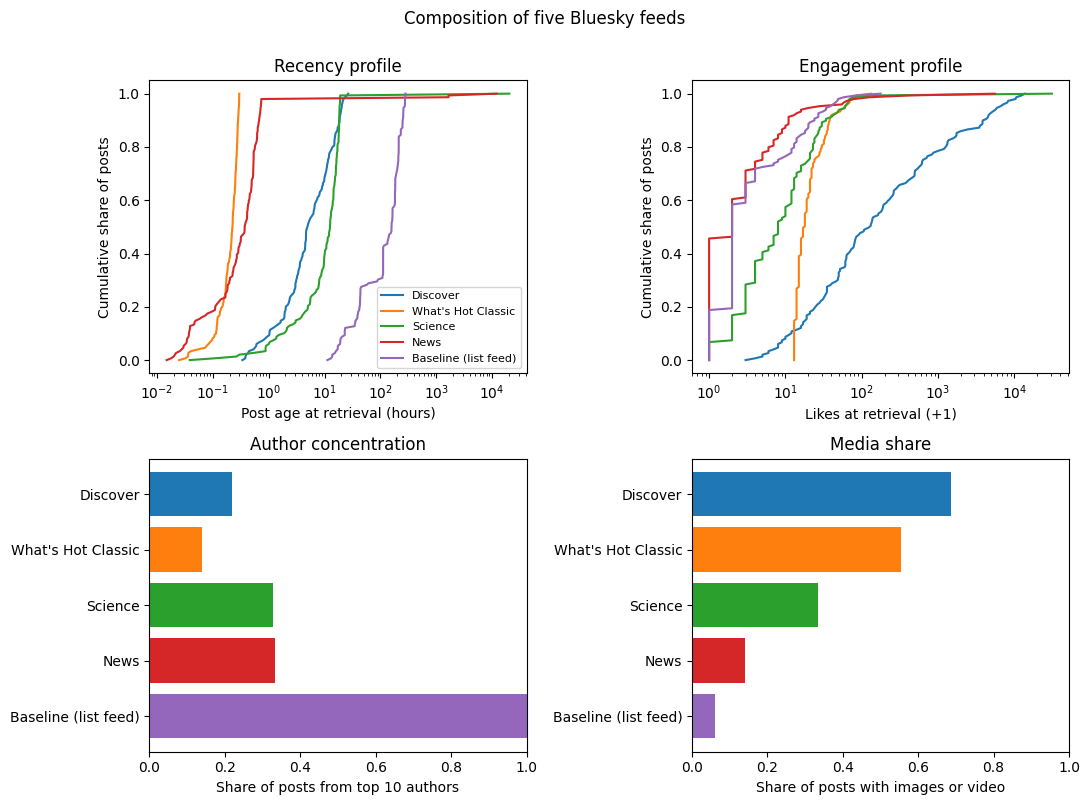

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
feed_names = list(comparison.index)
colors = plt.cm.tab10(np.linspace(0, 1, 10))[: len(feed_names)]

# (a) ECDF of post age at retrieval
ax = axes[0, 0]
for name, color in zip(feed_names, colors):
    ages = posts_df.loc[posts_df['feed'] == name, 'age_hours'].dropna().sort_values()
    ax.plot(ages, np.linspace(0, 1, len(ages)), label=name, color=color)
ax.set_xscale('log')
ax.set_xlabel('Post age at retrieval (hours)')
ax.set_ylabel('Cumulative share of posts')
ax.set_title('Recency profile')
ax.legend(fontsize=8)

# (b) ECDF of like counts
ax = axes[0, 1]
for name, color in zip(feed_names, colors):
    likes = posts_df.loc[posts_df['feed'] == name, 'like_count'].sort_values() + 1
    ax.plot(likes, np.linspace(0, 1, len(likes)), label=name, color=color)
ax.set_xscale('log')
ax.set_xlabel('Likes at retrieval (+1)')
ax.set_ylabel('Cumulative share of posts')
ax.set_title('Engagement profile')

# (c) Top-10 author share
ax = axes[1, 0]
ax.barh(feed_names[::-1], comparison['top10_author_share'][::-1], color=colors[::-1])
ax.set_xlabel('Share of posts from top 10 authors')
ax.set_title('Author concentration')
ax.set_xlim(0, 1)

# (d) Media share
ax = axes[1, 1]
ax.barh(feed_names[::-1], comparison['media_share'][::-1], color=colors[::-1])
ax.set_xlabel('Share of posts with images or video')
ax.set_title('Media share')
ax.set_xlim(0, 1)

fig.suptitle('Composition of five Bluesky feeds', y=1.0)
fig.tight_layout()
fig.savefig(Path('data') / 'feed_composition.png', dpi=150, bbox_inches='tight')

### What the differences reveal

Your numbers will differ from ours — these are live feeds — but the *structure* of the contrasts is stable, and each one tells you something about the curation logic behind the feed:

* **Ranked feeds select on engagement.** Median likes in the engagement-ranked feeds run one to two orders of magnitude above the chronological baseline, with Discover's gap typically the largest. Nothing about the algorithm *caused* that engagement; the feed conditions on it. This is the selection effect that makes naive "posts on the algorithmic feed get more likes!" claims circular.
* **Recency is a design choice.** Trending-style feeds serve posts that are mostly hours old, with a sharp upper bound — staleness is filtered out. The chronological baseline's age profile, by contrast, is just the posting rhythm of its roster: if the roster is quiet, the feed reaches days into the past.
* **Concentration reflects the eligible population.** Topical, allowlist-style feeds (Science, News) draw from a vetted roster of accounts, so a handful of prolific institutional accounts can dominate — high top-10 share and HHI. A network-wide trending feed samples from millions of eligible authors, so its concentration is low *within one snapshot*. And note the baseline: with only a few dozen accounts on the roster, its concentration is high by construction — concentration metrics are only comparable across feeds with similar eligible populations, a classic denominator subtlety.
* **Language and media mixes expose filters and incentives.** A feed's English share and media share tell you whether it filters by language or rewards visual content. (One measurement caveat: `lang` is *self-declared* by posting clients, and institutional accounts — like the news organizations here — often omit it, so a low `share_english` can mean undeclared rather than non-English.) — differences in exposure that Bandy & Diakopoulos (2021) showed can meaningfully reshape what news users encounter.

## 4. Audience overlap between feeds

Do these feeds amplify the *same people*? For each pair of feeds we compute the **Jaccard similarity** of their author sets:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

which is 0 when two feeds share no authors and 1 when they amplify identical sets. `feeds.author_jaccard` builds the full pairwise matrix.

In [15]:
overlap = feeds.author_jaccard(posts_df)
overlap.round(3)

,Discover,What's Hot Classic,Science,News,Baseline (list feed)
Discover,1.000,0.004,0.000,0.021,0.0
What's Hot Classic,0.004,1.000,0.004,0.010,0.0
Science,0.000,0.004,1.000,0.000,0.0
News,0.021,0.010,0.000,1.000,0.0
Baseline (list feed),0.000,0.000,0.000,0.000,1.0


A pairwise matrix is easier to scan as a heatmap. Each cell is the Jaccard similarity between the author sets of the row feed and the column feed; the diagonal is 1 by definition (every feed overlaps perfectly with itself), and we annotate each cell with its value so you do not have to squint at the colorbar.

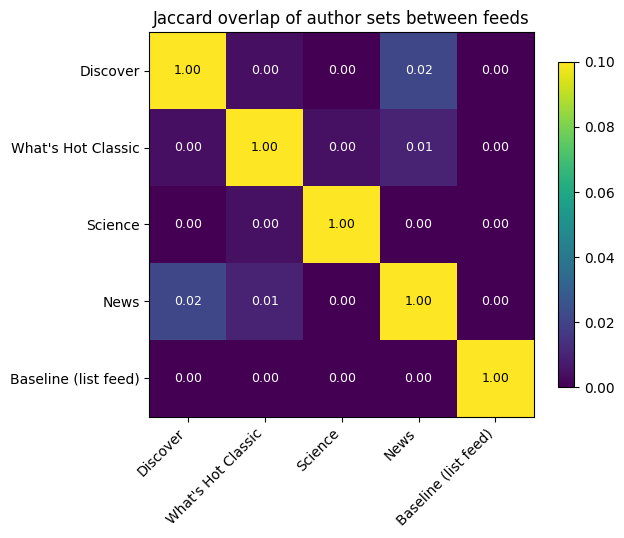

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
matrix = overlap.astype(float).values
image = ax.imshow(matrix, cmap='viridis', vmin=0, vmax=max(0.10, np.nanmax(matrix[~np.eye(len(matrix), dtype=bool)])))
ax.set_xticks(range(len(overlap)), overlap.columns, rotation=45, ha='right')
ax.set_yticks(range(len(overlap)), overlap.index)
for i in range(len(overlap)):
    for j in range(len(overlap)):
        ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if matrix[i, j] < 0.5 else 'black', fontsize=9)
ax.set_title('Jaccard overlap of author sets between feeds')
fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()

The headline finding is usually how *small* these overlaps are: in a single snapshot, each feed amplifies a nearly disjoint set of authors. Custom feeds are not five windows onto one conversation — they carve the network into largely separate audiences and speaker populations. (Which cells are nonzero will fluctuate between runs; when overlap appears at all, it usually involves Discover, whose network-wide eligibility pool brushes against the topical feeds.)

For a research design, this is the dependent variable in miniature: *exposure diversity*. With repeated snapshots you could ask whether feeds' author populations churn or ossify over time, and whose voices never appear in any algorithmic feed at all.

## 5. Lists: shared rosters for curation and moderation

Lists are the simplest governance object on Bluesky: a public, named roster of accounts (`app.bsky.graph.list` records). One mechanism, two very different uses, distinguished by the record's `purpose` field:

* **`curatelist`** — content curation: a list feed (as in our baseline), or a roster to pin and browse.
* **`modlist`** — moderation: users who subscribe to a moderation list can mute or block *every member at once*. Shared blocklists, which emerged on Twitter as a grassroots harassment defense, are first-class protocol objects here.
* **`referencelist`** — internal rosters referenced by other records (starter packs use these).

`app.bsky.graph.getLists` enumerates an account's published lists, and `app.bsky.graph.getList` pages through a list's members.

In [17]:
lists_df = pd.DataFrame(
    [
        {
            'name': l.name,
            'purpose': l.purpose.split('#')[-1],
            'members': l.list_item_count,
            'description': (l.description or '').replace('\n', ' ')[:80],
            'uri': l.uri,
        }
        for l in lists_response.lists
    ]
)
print(f"{len(lists_df)} list(s) published by bsky.app")
lists_df

1 list(s) published by bsky.app


,name,purpose,members,description,uri
0,Community Showcase,curatelist,21,Community projects built on the Bluesky API ✨,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...


Who is actually *on* a list? `app.bsky.graph.getList` ([docs](https://docs.bsky.app/docs/api/app-bsky-graph-get-list)) pages through a list's members with the same cursor pattern as every other paginated endpoint in this series: request a page, keep the returned `cursor`, pass it back to get the next page, stop when the cursor is empty or our cap is reached. Let's unpack the curation list we used as our chronological baseline in Section 2, so we can see exactly whose posts that baseline sample contained.

In [18]:
if baseline_list is not None:
    members = []
    cursor = None
    while len(members) < 200:  # cap, as always
        page = client.app.bsky.graph.get_list(
            {'list': baseline_list.uri, 'limit': 100, **({'cursor': cursor} if cursor else {})}
        )
        members.extend(page.items)
        cursor = page.cursor
        if not cursor:
            break
        time.sleep(0.1)

    members_df = pd.DataFrame(
        [
            {
                'handle': m.subject.handle,
                'display_name': m.subject.display_name,
                'description': (m.subject.description or '').replace('\n', ' ')[:60],
            }
            for m in members
        ]
    )
    print(f"'{baseline_list.name}' ({baseline_list.purpose.split('#')[-1]}) - {len(members_df)} members")
    display(members_df.head(10))
else:
    print('No list available to unpack.')

'Community Showcase' (curatelist) - 21 members


,handle,display_name,description
0,boostblue.bsky.social,Boost Blue,Alt Bluesky app for iOS and Android: - Full iP...
1,tangled.org,Tangled,https://tangled.org is the next-generation soc...
2,stream.place,Streamplace,Solving video for everybody forever. Starting ...
3,smokesignal.events,Smoke Signal,"Find events, make connections, and create comm..."
4,skylight.social,Skylight Social,"✨Join Skylight, report bugs, suggest features:..."
5,skyfeed.app,SkyFeed App,"SkyFeed is a real-time client for Bluesky, ava..."
6,skycord.app,SkyCord,Developer: @midnightwolf.bsky.social Donations...
7,sill.social,Sill,Top news shared by the people you trust. A lin...
8,rocksky.app,Rocksky,A decentralized music tracking and discovery p...
9,popfeed.social,Popfeed,The home of pop culture in the Atmosphere iOS...


Membership on a list is consequential and *non-consensual*: accounts do not opt in to being listed, and inclusion on a widely-subscribed moderation list can silently sever someone from a large audience. That makes lists a rich research site — who maintains influential modlists, how membership changes over time, what the error rates look like — and also a sensitive one: a dataset of "accounts on blocklist X" is effectively an accusation attached to identities. Aggregate analyses are usually the right level of reporting.

## 6. Starter packs: curating the network itself

Starter packs (`app.bsky.graph.starterpack` records) bundle a reference list of accounts — and optionally feeds — into a shareable onboarding page. A newcomer who joins through a starter pack can follow everyone on it with one tap. Where feeds curate *content*, starter packs curate the *follow graph*: they decide which corner of the network a new user lands in.

`app.bsky.graph.getActorStarterPacks` lists an account's published packs, with counts of how many users joined through each.

In [19]:
starter_packs = client.app.bsky.graph.get_actor_starter_packs({'actor': 'bsky.app', 'limit': 50})

packs_df = pd.DataFrame(
    [
        {
            'name': sp.record.name,
            'accounts': sp.list_item_count,
            'joined_this_week': sp.joined_week_count,
            'joined_all_time': sp.joined_all_time_count,
            'created': str(sp.record.created_at)[:10],
        }
        for sp in starter_packs.starter_packs
    ]
)
print(f"{len(packs_df)} starter packs published by bsky.app")
packs_df

11 starter packs published by bsky.app


,name,accounts,joined_this_week,joined_all_time,created
0,June 9 Elections,None,0,0,2026-06-08
1,US Election Reporters and Analysts,None,0,0,2026-06-02
2,June 2 Elections,None,0,0,2026-06-02
3,May 19 Primaries,None,0,1,2026-05-18
4,Ohio Primaries,None,0,0,2026-05-05
5,Illinois Primaries,None,0,0,2026-03-14
6,Oscars,None,0,0,2026-03-13
7,Texas Primaries,None,0,0,2026-03-03
8,🏈 NFL Conference Championships,None,0,17,2025-04-24
9,🏀 NBA Playoffs on Bluesky,None,0,1,2025-04-19


Notice the editorial rhythm: the official account spins up packs around scheduled events — elections, playoffs, award shows — pre-assembling an audience for each. Let's unpack one. A starter pack's accounts live in an ordinary reference list, so we fetch the pack with `app.bsky.graph.getStarterPack` and then read its list members with the same `getList` call as before.

In [20]:
# Pick the pack the most users have actually joined through
top_pack = max(starter_packs.starter_packs, key=lambda sp: sp.joined_all_time_count or 0)
pack_view = client.app.bsky.graph.get_starter_pack({'starter_pack': top_pack.uri}).starter_pack

print(f"Starter pack: {pack_view.record.name!r}")
print(f"Description:  {(pack_view.record.description or '(none)')[:100]}")
print(f"Joined through it: {pack_view.joined_all_time_count} accounts all-time")

if pack_view.list:
    pack_members = client.app.bsky.graph.get_list({'list': pack_view.list.uri, 'limit': 100})
    pack_members_df = pd.DataFrame(
        [{'handle': m.subject.handle, 'display_name': m.subject.display_name} for m in pack_members.items]
    )
    print(f"\nAccounts in the pack ({len(pack_members_df)}):")
    display(pack_members_df.head(15))
else:
    print('This pack has no account list attached.')

Starter pack: '🏈 NFL Conference Championships'
Description:  Follow some of our favorite football posters for updates on the AFC and NFC Championship Games
Joined through it: 17 accounts all-time

Accounts in the pack (44):


,handle,display_name
0,rayratto.bsky.social,Ray Ratto
1,lpp.bsky.social,Luis Paez-Pumar
2,izdaramola.bsky.social,Daramola
3,barryp.bsky.social,Barry Petchesky
4,laurentheisen.bsky.social,Lauren Theisen
5,albertburneko.bsky.social,Albert Burneko
6,mckinneykelsey.bsky.social,Kelsey McKinney
7,troyrenck.bsky.social,Troy Renck
8,adamgrosbard.bsky.social,Adam Grosbard
9,nateatkins.bsky.social,Nate Atkins


### Starter packs as a natural experiment

For network science, starter packs are a gift: a *measurable treatment* in network formation. Two users who join Bluesky in the same week through different starter packs receive different initial follow neighborhoods — assigned largely by whichever link happened to reach them, not by slowly homegrown homophily. Because pack membership, join counts, and the full follow graph (Part 03) are all public, you can ask classic questions with unusual leverage:

* Do users seeded into different packs end up in durably different communities, or does organic rewiring wash out the initial conditions?
* How much of an account's long-run audience traces back to starter-pack placement — a *Matthew effect* with an observable origin?
* Do packs accelerate the early-follower accumulation that Part 04's diffusion models treat as exogenous?

The identification is not free — who joins through which pack is not random — but compared with inferring initial conditions retrospectively, an explicit, timestamped onboarding bundle is about as close to a natural experiment in network formation as platforms provide.

## 7. Labels and stackable moderation

The third leg of Bluesky's governance stack is moderation. Instead of one company applying one policy, AT Protocol moderation is performed by **labelers**: independent services that publish *labels* — small signed records attaching a value like `porn`, `graphic-media`, `rude`, or the hide-everything `!takedown` — to accounts, posts, and other records (see the [moderation architecture docs](https://docs.bsky.app/docs/advanced-guides/moderation)). Users subscribe to labelers (Bluesky's own labeler is just the default subscription), and each client decides how to render each label: hide, warn, badge, or ignore. This is what Bluesky calls **stackable moderation** — many overlapping moderation authorities instead of one — introduced in their blog post ["Bluesky's Stackable Approach to Moderation"](https://bsky.social/about/blog/03-12-2024-stackable-moderation), which is worth reading in full as a design statement about who should hold moderation power.

Crucially for researchers, labelers are *queryable services*. The Bluesky Moderation Service (`moderation.bsky.app`) answers `com.atproto.label.queryLabels` at `https://mod.bsky.app`. First, let's read its public "policy menu" — the set of label values it may emit — via `app.bsky.labeler.getServices`.

In [21]:
try:
    services = client.app.bsky.labeler.get_services({'dids': [feeds.BSKY_MOD_DID], 'detailed': True})
    service_view = services.views[0]
    print(f"Labeler: {service_view.creator.handle} ({service_view.creator.did})")
    print(f"Liked (subscribed) by {service_view.like_count:,} accounts")
    print(f"\nLabel values this service may emit:")
    print(', '.join(service_view.policies.label_values))
except Exception as error:
    print(f"getServices unavailable ({type(error).__name__}: {error})")

Labeler: moderation.bsky.app (did:plc:ar7c4by46qjdydhdevvrndac)
Liked (subscribed) by 997 accounts

Label values this service may emit:
!hide, !warn, porn, sexual, nudity, sexual-figurative, graphic-media, self-harm, sensitive, extremist, intolerant, threat, rude, illicit, security, unsafe-link, impersonation, misinformation, scam, engagement-farming, spam, rumor, misleading, inauthentic


Now the audit question: **do any of the posts our feeds served carry moderation labels?** `feeds.query_labels` batches `uriPatterns` (25 per request, politely spaced, capped) against the labeler. We query the exact URIs of up to 300 posts from our archive.

In [22]:
post_uris = posts_df['uri'].drop_duplicates().tolist()[:300]
post_labels = feeds.query_labels(post_uris)
post_labels_df = feeds.labels_to_dataframe(post_labels)

print(f"Queried {len(post_uris)} post URIs from our five feed samples -> {len(post_labels_df)} labels found")
if len(post_labels_df):
    display(post_labels_df['val'].value_counts())
else:
    print("\nZero labels is itself a finding: by the time a post reaches a curated feed, it has")
    print("already survived several filters - feed generators exclude labeled content, and the")
    print("AppView suppresses taken-down posts before we ever see them. The moderated layer of")
    print("the network is invisible *from inside the feeds*.")

Queried 300 post URIs from our five feed samples -> 22 labels found


val
porn      20
sexual     2
Name: count, dtype: int64

Labels are sparse on curated-feed posts because curation and moderation interact: most labeled content never *reaches* a feed, and what the AppView has taken down we never see at all. When a handful of labels do appear (in our run, a few adult-content labels on feed posts), notice what that teaches: a label does not delete anything. The post sits in the feed's public skeleton *with its label attached*, and each user's client decides — based on their labeler subscriptions and preferences — whether to hide, blur, or show it. Moderation here is metadata, not removal. To confirm the labeler is far from idle, we can widen the query. `queryLabels` accepts wildcard patterns like `at://did:plc:.../*`, which return labels on *any record in an account's history*. We take a seeded random sample of 50 authors from our archive and ask whether anything in their histories has ever been labeled — reporting only aggregate label values, not who received them.

In [23]:
rng = np.random.default_rng(42)
author_dids = posts_df['author_did'].unique()
sampled_dids = rng.choice(author_dids, size=min(50, len(author_dids)), replace=False)

history_labels = feeds.query_labels([f'at://{did}/*' for did in sampled_dids])
history_labels_df = feeds.labels_to_dataframe(history_labels)
active = history_labels_df[~history_labels_df['neg']]  # drop retracted (negated) labels

print(f"Labels anywhere in the history of {len(sampled_dids)} sampled authors: {len(active)}")
print("(each response is capped at 250 labels, so counts are lower bounds)\n")
if len(active):
    print(active['val'].value_counts().to_string())
else:
    print('No labels found in this sample.')

Labels anywhere in the history of 50 sampled authors: 478
(each response is capped at 250 labels, so counts are lower bounds)

val
porn             377
sexual            95
nudity             4
graphic-media      2


So the moderation layer is busy — mostly with content-classification labels (`sexual`, `porn`, `graphic-media`) that drive the client-side warnings users can configure — it just operates on a different slice of the network than the curated feeds surface. The two-step pattern we used here (exact URIs for your sample, wildcard histories for context) is a reusable template for studying *label prevalence*: which kinds of accounts and content get labeled, by which labelers, and how labels and algorithmic amplification interact.

A caution before you build that study: labels are moderation *actions*, and a row like "account X was labeled `rude`" is an allegation attached to an identity. Report prevalence in aggregate, and remember that third-party labelers vary enormously in standards and accountability.

## 8. Reproducibility: working from the saved archive

Both artifacts of our audit are on disk — `data/feed_posts.parquet` (one slim row per post, including its retrieval timestamp) and `data/feed_comparison.csv` (the metric table). Every analysis cell above Section 3 can be rerun *from the files* without touching the network, which is how you should hand an audit to a collaborator: the feeds will have moved on, but your snapshot is frozen and documented.

In [24]:
archive = pd.read_parquet('data/feed_posts.parquet')
saved_comparison = pd.read_csv('data/feed_comparison.csv', index_col='feed')

print(f"Reloaded {len(archive)} posts; collected on "
      f"{archive['retrieved_at'].dt.date.min()} (UTC)\n")

# A reanalysis straight from disk: engagement by feed
archive.groupby('feed')[['like_count', 'repost_count']].median()

Reloaded 749 posts; collected on 2026-06-10 (UTC)



,like_count,repost_count
feed,,
Baseline (list feed),1.0,0.0
Discover,125.5,21.0
News,1.0,0.0
Science,7.0,2.0
What's Hot Classic,16.5,3.0


## 9. Research design: algorithm audits without platform cooperation

Step back and compare the designs available to you here against the Twitter-era studies we started from:

* **Huszár et al. (2022)** needed Twitter's own servers and a years-long holdback experiment to compare algorithmic against chronological timelines. On Bluesky, the *public skeleton* of that comparison — what each published algorithm serves versus a chronological feed — took us a few hundred unauthenticated HTTP requests. No permission, no NDA, no API key.
* **Bandy & Diakopoulos (2021)** had to build sock puppets to observe curated timelines from outside. On Bluesky the equivalent observation is an endpoint. But their problem has not disappeared — it has moved. What we audited is the **feed skeleton**: the generic, viewer-independent output. A logged-in user's Discover feed is personalized, and *that* layer is exactly as invisible to us as Twitter's timeline was. Sock-puppet designs (consented panels of real users donating their feed views, or instrumented research accounts) remain necessary to study personalization, and Bluesky's open protocol makes such panels far easier to instrument.
* **The governance stack is itself a study population.** Thousands of feed generators, labelers, lists, and starter packs — each with public metadata, subscriber counts, and queryable outputs — form an ecosystem of *competing curation and moderation authorities*. Who runs them? Which gain audiences? Do third-party labelers converge with or diverge from the platform's own decisions? Does stackable moderation actually redistribute governance power, or does everyone stay on the defaults? These questions have no Twitter-era analogue, because the infrastructure they ask about did not exist.

The general lesson: on an open protocol, the unit of audit shifts from "the algorithm" to *an ecology of algorithms*, and the scarce resource shifts from access to **design** — choosing baselines, denominators, and snapshots that make the comparison meaningful.

## Ethics and limitations

**Ethics.** Everything we queried is public infrastructure, but the people inside it did not opt into research. Posts surfaced by feeds, accounts on lists, and labeled records all belong to users who mostly do not know these endpoints exist. We practiced minimization (no post text in the archive — our composition questions did not need it), reported labels and list memberships in aggregate rather than naming accounts, and capped every collection loop. Moderation data deserves extra care: labels and modlist memberships are accusations as well as data points, and republishing them attached to identities can amplify the very harms moderation tries to contain. And remember that feed *publishers* are people too — small hobbyist feeds can identify their one maintainer.

**Limitations.** Our audit observed each feed once, unauthenticated. That means: (1) **no personalization** — we saw the generic skeleton, not what any actual user sees, and for feeds like Discover the personalized layer may dominate; (2) **single snapshot** — feeds are moving targets, and one retrieval confounds the algorithm with the moment (a serious audit repeats collection across times of day and weeks); (3) **selection, not effects** — composition differences show what feeds *select*, not what they *cause*; engagement comparisons especially are selection effects by construction; (4) **survivorship** — the AppView already filters taken-down and blocked content before we see it, which is exactly why our label query on feed posts came back empty; (5) **a platform in flux** — feed rosters, labeler policies, and even lexicon types (we met a brand-new embed type the SDK didn't know) change continuously, which is why the archive records its collection timestamps and why your numbers will not match ours.

## Exercises

The exercises below extend the notebook, roughly in increasing order of effort. All of them can be done unauthenticated.

1. **Add another feed to the audit.** Pick a popular community feed (browse [getSuggestedFeeds](https://docs.bsky.app/docs/api/app-bsky-feed-get-suggested-feeds) output from Section 1, or the Feeds tab in the app) and add it to `CANDIDATE_FEEDS`, then rerun Sections 2–4. A feed's page URL `https://bsky.app/profile/<handle>/feed/<rkey>` maps to the AT-URI `at://<DID>/app.bsky.feed.generator/<rkey>`; resolve the handle to a DID with `com.atproto.identity.resolveHandle`. How does the newcomer's composition profile compare?

2. **Bigger samples.** Raise `target` from 150 to 500 in `feeds.fetch_feed_posts` and recompute the composition table. Which metrics are stable and which shift? Concentration measures like Gini and HHI are sensitive to sample size (more posts means more chances for rare authors to appear), so this exercise doubles as a lesson in not comparing concentration across samples of different sizes.

3. **Compare label prevalence across feeds.** Section 7 pooled all post URIs into one label query. Instead, group `posts_df` by feed, query labels separately for each feed's URIs (and, with wildcard patterns, its authors' histories), and report labels per 100 posts per feed. Do allowlist-style feeds (Science, News) have cleaner histories than the open trending feeds?

4. **Track one feed's composition across a day.** Rerun the Section 2 collection for a single feed every few hours, appending each snapshot (the `retrieved_at` column already distinguishes them) to a growing Parquet file. Plot median post age, median likes, and top-10 author share over the day — is the feed's character stable, or does it breathe with the diurnal cycle from Part 05?

5. **Author churn between snapshots.** With two snapshots of the same feed from Exercise 4, compute the Jaccard similarity of the feed's author set *with itself across time*. High self-overlap means the feed amplifies a stable cast; low self-overlap means it churns. Compare churn between an algorithmic feed and the chronological baseline.

6. **Starter-pack roster overlap.** Fetch the member lists of several of `bsky.app`'s starter packs (Section 6) and compute pairwise Jaccard overlap between their rosters, reusing the logic of `feeds.author_jaccard`. Do the packs partition accounts into disjoint bundles, or is there a core of accounts the platform inserts into every newcomer's network?

## Research project ideas

**1. A longitudinal audit of the feed marketplace.** *Question:* do popular custom feeds diversify exposure relative to the official Discover feed, or do they converge on the same engagement-bait equilibrium? *Data:* daily snapshots, over four to eight weeks, of the top ~25 feeds from `getSuggestedFeeds` plus Discover — composition metrics and author sets per feed per day, collected with the resilient pipeline from Section 2. *Method:* model each composition metric as a panel (feed × day), compare ranked feeds against chronological list-feed baselines, and track exposure diversity as the union and overlap of author sets over time, in the spirit of Bandy & Diakopoulos (2021). *Expected challenge:* third-party feed generators appear, disappear, and error intermittently, so the collection design must treat missingness as data (which feeds die?) rather than as a nuisance, and concentration metrics must be compared at fixed sample sizes.

**2. Starter packs and network formation.** *Question:* does the initial follow neighborhood a newcomer receives from a starter pack durably shape the community they end up in, or does organic rewiring wash out initial conditions? *Data:* a roster of active starter packs with join counts; cohorts of recently created accounts whose first-day follows closely match a pack's roster (a behavioral signature of joining through it); repeated crawls of those accounts' follow graphs over subsequent months using Part 03's methods. *Method:* community detection on the evolving follow graph, comparing users seeded by different packs but matched on join week and early activity; survival analysis of which seeded follows persist versus get pruned. *Expected challenge:* identification — who joins through which pack is not random (a gardening pack recruits gardeners), so the design needs matched comparisons and falsification tests, and the "joined via pack" inference itself has measurement error worth validating.

**3. Labeler governance: do independent moderators agree?** *Question:* how much do third-party labelers' decisions converge with the platform's own moderation service, and where they diverge, in which direction? *Data:* the public policy menus (`getServices`) of the Bluesky Moderation Service and a roster of prominent third-party labelers; labels queried from each labeler's own service endpoint (`queryLabels` with each labeler's `base_url`) for a common random sample of accounts and posts. *Method:* map each labeler's label values onto a shared category scheme, then compute prevalence per labeler and inter-labeler agreement (e.g., Cohen's κ) per category — a direct empirical test of whether stackable moderation produces redundant or genuinely plural governance. *Expected challenge:* labelers differ wildly in scope, taxonomy, and uptime, so the category mapping is itself a contestable research decision to document; and because labels are accusations attached to identities, results must be reported strictly in aggregate.

## References

### Scholarship

* Huszár, F., Ktena, S. I., O'Brien, C., Belli, L., Schlaikjer, A., & Hardt, M. (2022). [Algorithmic amplification of politics on Twitter](https://doi.org/10.1073/pnas.2025334119). *Proceedings of the National Academy of Sciences*, 119(1), e2025334119.
* Bandy, J., & Diakopoulos, N. (2021). [More accounts, fewer links: How algorithmic curation impacts media exposure in Twitter timelines](https://doi.org/10.1145/3449152). *Proceedings of the ACM on Human-Computer Interaction*, 5(CSCW1), 1–28.
* Sandvig, C., Hamilton, K., Karahalios, K., & Langbort, C. (2014). [Auditing algorithms: Research methods for detecting discrimination on internet platforms](https://websites.umich.edu/~csandvig/research/Auditing%20Algorithms%20--%20Sandvig%20--%20ICA%202014%20Data%20and%20Discrimination%20Preconference.pdf). Paper presented at *Data and Discrimination*, ICA preconference.
* Metaxa, D., Park, J. S., Robertson, R. E., Karahalios, K., Wilson, C., Hancock, J., & Sandvig, C. (2021). [Auditing algorithms: Understanding algorithmic systems from the outside in](https://doi.org/10.1561/1100000083). *Foundations and Trends in Human–Computer Interaction*, 14(4), 272–344.

### Documentation

* Bluesky (2024). [Bluesky's stackable approach to moderation](https://bsky.social/about/blog/03-12-2024-stackable-moderation). Bluesky blog, March 12, 2024.

Protocol and API documentation: [AT Protocol](https://atproto.com) · [Lexicon guide](https://atproto.com/guides/lexicon) · [AT-URI scheme](https://atproto.com/specs/at-uri-scheme) · [Custom feed starter template](https://docs.bsky.app/docs/starter-templates/custom-feeds) · [Feed generators](https://docs.bsky.app/docs/advanced-guides/custom-feeds) · [Moderation and labelers](https://docs.bsky.app/docs/advanced-guides/moderation) · [Lists](https://docs.bsky.app/docs/api/app-bsky-graph-get-list) · [Starter packs](https://docs.bsky.app/docs/api/app-bsky-graph-get-starter-pack)